In [1]:
from idlelib.debugger_r import restart_subprocess_debugger

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout, Activation, Conv2D, MaxPooling2D, Flatten, BatchNormalization
from keras.utils import plot_model
from keras.datasets import cifar10
import matplotlib.pyplot as plt
import numpy as np


In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

In [3]:
x_train.shape,x_test.shape

((50000, 32, 32, 3), (10000, 32, 32, 3))

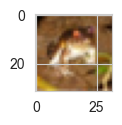

In [4]:
plt.figure(figsize=(1,1))
plt.imshow(x_train[0])

In [5]:
y_train[0]

array([6], dtype=uint8)

In [6]:
labels=['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

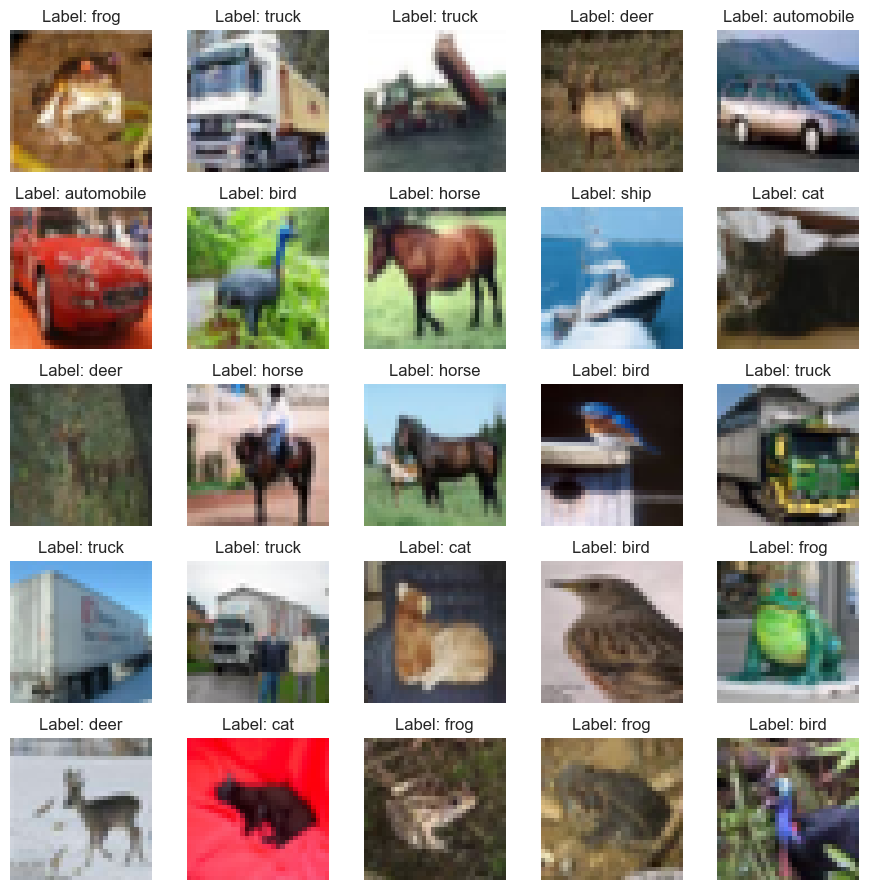

In [7]:
plt.figure(figsize=(9,9))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f'Label: {labels[y_train[i][0]]}')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [8]:
x_train=x_train/255
x_test=x_test/255

In [9]:
#Build the model
model = Sequential()
model.add(Input(shape=(32,32,3)))

model.add(Conv2D(filters=16,kernel_size=(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.1))

model.add(Conv2D(filters=32,kernel_size=(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dense(128,activation='relu'))
model.add(Dense(10, activation='softmax'))

In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 334,442 (1.28 MB)

 Trainable params: 334,442 (1.28 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy, optimizer='adam', metrics=['accuracy'])

In [12]:
model.fit(x_train, y_train, epochs=15, batch_size=10, verbose =2)

Epoch 1/15
5000/5000 - 31s - 6ms/step - accuracy: 0.4823 - loss: 1.4280
Epoch 2/15
5000/5000 - 30s - 6ms/step - accuracy: 0.6164 - loss: 1.0821
Epoch 3/15
5000/5000 - 32s - 6ms/step - accuracy: 0.6704 - loss: 0.9341
Epoch 4/15
5000/5000 - 30s - 6ms/step - accuracy: 0.7091 - loss: 0.8299
Epoch 5/15
5000/5000 - 32s - 6ms/step - accuracy: 0.7379 - loss: 0.7446
Epoch 6/15
5000/5000 - 31s - 6ms/step - accuracy: 0.7588 - loss: 0.6773
Epoch 7/15
5000/5000 - 30s - 6ms/step - accuracy: 0.7832 - loss: 0.6121
Epoch 8/15
5000/5000 - 30s - 6ms/step - accuracy: 0.8009 - loss: 0.5598
Epoch 9/15
5000/5000 - 29s - 6ms/step - accuracy: 0.8192 - loss: 0.5066
Epoch 10/15
5000/5000 - 30s - 6ms/step - accuracy: 0.8340 - loss: 0.4655
Epoch 11/15
5000/5000 - 30s - 6ms/step - accuracy: 0.8470 - loss: 0.4306
Epoch 12/15
5000/5000 - 30s - 6ms/step - accuracy: 0.8574 - loss: 0.3982
Epoch 13/15
5000/5000 - 29s - 6ms/step - accuracy: 0.8685 - loss: 0.3735
Epoch 14/15
5000/5000 - 29s - 6ms/step - accuracy: 0.8771 - 

In [13]:
model.evaluate(x_test, y_test,batch_size=1)

10000/10000 ━━━━━━━━━━━━━━━━━━━━ 27s 3ms/step - accuracy: 0.6684 - loss: 1.3716


[1.3716264963150024, 0.66839998960495]

In [14]:
import cv2
img=cv2.imread('images/dog.jpg')
img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

In [15]:
img=cv2.resize(img,(32,32))
img=img.reshape(1,32,32,3)
img=img/255

In [16]:
pred=np.argmax(model.predict(img))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step


In [17]:
labels[pred]

'dog'

In [20]:
img = cv2.imread('images/plane.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (32, 32))
img = img.reshape(1, 32, 32, 3)
img = img / 255
pred = np.argmax(model.predict(img))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


In [22]:
labels[pred]

'airplane'